<a href="https://colab.research.google.com/github/NguyenTien-beep/Study_In_DPL_302/blob/main/Report_01/DPL302_Group_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [33]:
# 2. LOAD DỮ LIỆU & XÂY DỰNG MA TRẬN KỀ
# ============================================
data_npz = np.load('pems04.npz')
traffic_data = data_npz['data']
flow_data = traffic_data[:, :, 0]  # (16992, 307)
num_nodes = flow_data.shape[1]

# Load khoảng cách
distance_df = pd.read_csv('distance.csv')
adj_matrix = np.zeros((num_nodes, num_nodes), dtype=np.float32)

# Ánh xạ ID cảm biến
unique_nodes = sorted(list(set(distance_df['from']).union(set(distance_df['to']))))
node_to_idx = {node: idx for idx, node in enumerate(unique_nodes)}

# Xây dựng ma trận kề với kernel Gaussian
distances = distance_df['cost'].values
sigma = np.std(distances)
for _, row in distance_df.iterrows():
    u = node_to_idx[int(row['from'])]
    v = node_to_idx[int(row['to'])]
    adj_matrix[u, v] = np.exp(-(row['cost']**2) / (sigma**2))
    adj_matrix[v, u] = adj_matrix[u, v]

# Chuẩn hóa ma trận kề (GCN Laplacian Normalization)
adj_matrix = adj_matrix + np.eye(num_nodes)
d_inv_sqrt = np.power(np.array(adj_matrix.sum(1)), -0.5).flatten()
d_inv_sqrt[np.isinf(d_inv_sqrt)] = 0
d_mat_inv_sqrt = np.diag(d_inv_sqrt)
normalized_adj = torch.tensor(d_mat_inv_sqrt @ adj_matrix @ d_mat_inv_sqrt, dtype=torch.float32).cuda()


# 2. TIỀN XỬ LÝ DỮ LIỆU & TẠO SLIDING WINDOW


In [34]:
scaler = MinMaxScaler()
scaled_flow = scaler.fit_transform(flow_data)

sequence_length = 12

# Tạo sliding window bằng NumPy (nhanh hơn vòng lặp)
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len, :])
        y.append(data[i+seq_len, :])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X, y = create_sequences(scaled_flow, sequence_length)

# Chia train/validation/test (70-15-15)
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)

X_train = torch.tensor(X[:train_size]).cuda()
y_train = torch.tensor(y[:train_size]).cuda()

X_val = torch.tensor(X[train_size:train_size+val_size]).cuda()
y_val = torch.tensor(y[train_size:train_size+val_size]).cuda()

X_test = torch.tensor(X[train_size+val_size:]).cuda()
y_test = torch.tensor(y[train_size+val_size:]).cuda()

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=64, shuffle=False)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")


Train: 11886, Val: 2547, Test: 2547


# 3. ĐỊNH NGHĨA KIẾN TRÚC MÔ HÌNH STGCN

In [36]:
class GraphConvolution(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight = nn.Parameter(torch.FloatTensor(in_features, out_features))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, x, adj):
        # x: (batch, seq_len, nodes)
        # adj: (nodes, nodes)
        x = x.permute(0, 2, 1)  # (batch, nodes, seq_len)
        out = torch.matmul(adj, torch.matmul(x, self.weight))  # SỬA: (nodes, nodes) @ (batch, nodes, out)
        return out.permute(0, 2, 1)  # (batch, out, nodes) -> (batch, seq_len, nodes)

class STGCNModel(nn.Module):
    def __init__(self, num_nodes, seq_len, hidden_dim=64):
        super().__init__()
        self.gcn1 = GraphConvolution(seq_len, hidden_dim)
        self.gcn2 = GraphConvolution(hidden_dim, hidden_dim)
        self.gru = nn.GRU(input_size=num_nodes, hidden_size=hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_nodes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x, adj):
        # x: (batch, seq_len, nodes)
        x = F.relu(self.gcn1(x, adj))
        x = self.dropout(x)
        x = F.relu(self.gcn2(x, adj))
        x = self.dropout(x)
        _, gru_out = self.gru(x)  # gru_out: (1, batch, hidden_dim)
        return self.fc(gru_out.squeeze(0))

model = STGCNModel(num_nodes, sequence_length).cuda()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

# 4. HUẤN LUYỆN

In [37]:
print("\n--- BẮT ĐẦU HUẤN LUYỆN ---")
best_val_loss = float('inf')
patience_counter = 0
early_stop_patience = 5

for epoch in range(50):
    # Training
    model.train()
    total_loss = 0
    for bx, by in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(bx, normalized_adj), by)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_train_loss = total_loss / len(train_loader)

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for bx, by in val_loader:
            loss = criterion(model(bx, normalized_adj), by)
            val_loss += loss.item()
    avg_val_loss = val_loss / len(val_loader)

    scheduler.step(avg_val_loss)

    # Early stopping & save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_stgcn_model.pth')
        patience_counter = 0
    else:
        patience_counter += 1

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.5f}, Val Loss = {avg_val_loss:.5f}, LR = {optimizer.param_groups[0]['lr']:.6f}")

    if patience_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

# Load best model
model.load_state_dict(torch.load('best_stgcn_model.pth'))
print("\n--- HUẤN LUYỆN HOÀN TẤT ---")



--- BẮT ĐẦU HUẤN LUYỆN ---
Epoch 5: Train Loss = 0.00558, Val Loss = 0.00546, LR = 0.001000
Epoch 10: Train Loss = 0.00485, Val Loss = 0.00495, LR = 0.001000
Epoch 15: Train Loss = 0.00436, Val Loss = 0.00466, LR = 0.001000
Epoch 20: Train Loss = 0.00405, Val Loss = 0.00454, LR = 0.001000
Epoch 25: Train Loss = 0.00387, Val Loss = 0.00443, LR = 0.001000
Epoch 30: Train Loss = 0.00375, Val Loss = 0.00426, LR = 0.001000
Epoch 35: Train Loss = 0.00366, Val Loss = 0.00423, LR = 0.001000
Epoch 40: Train Loss = 0.00358, Val Loss = 0.00420, LR = 0.001000
Epoch 45: Train Loss = 0.00346, Val Loss = 0.00410, LR = 0.000500
Epoch 50: Train Loss = 0.00344, Val Loss = 0.00408, LR = 0.000500

--- HUẤN LUYỆN HOÀN TẤT ---


# 5. ĐÁNH GIÁ VÀ KHỬ CHUẨN HÓA (ĐỂ CÓ ĐƠN VỊ XE THẬT)

In [38]:
def smape(y_true, y_pred):
    """Symmetric Mean Absolute Percentage Error"""
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    diff = np.abs(y_true - y_pred) / denominator
    diff[denominator == 0] = 0
    return np.mean(diff) * 100

def wmape(y_true, y_pred):
    """Weighted Mean Absolute Percentage Error"""
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100

model.eval()
with torch.no_grad():
    predictions = model(X_test, normalized_adj).cpu().numpy()
    y_true = y_test.cpu().numpy()

# Inverse transform về đơn vị xe thực tế
preds_rescaled = scaler.inverse_transform(predictions)
true_rescaled = scaler.inverse_transform(y_true)

# Tính toán các chỉ số
mae = mean_absolute_error(true_rescaled, preds_rescaled)
rmse = np.sqrt(mean_squared_error(true_rescaled, preds_rescaled))
smape_value = smape(true_rescaled, preds_rescaled)
wmape_value = wmape(true_rescaled, preds_rescaled)

print("\n" + "="*50)
print("KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH STGCN")
print("="*50)
print(f"MAE  (Mean Absolute Error)     : {mae:.4f} vehicles")
print(f"RMSE (Root Mean Square Error)  : {rmse:.4f} vehicles")
print(f"sMAPE (Symmetric MAPE)         : {smape_value:.2f}%")
print(f"WMAPE (Weighted MAPE)          : {wmape_value:.2f}%")
print("="*50)


KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH STGCN
MAE  (Mean Absolute Error)     : 22.5009 vehicles
RMSE (Root Mean Square Error)  : 38.0167 vehicles
sMAPE (Symmetric MAPE)         : 15.67%
WMAPE (Weighted MAPE)          : 10.13%


# PHẦN 6: BIỂU ĐỒ SO SÁNH THỰC TẾ VS DỰ ĐOÁN

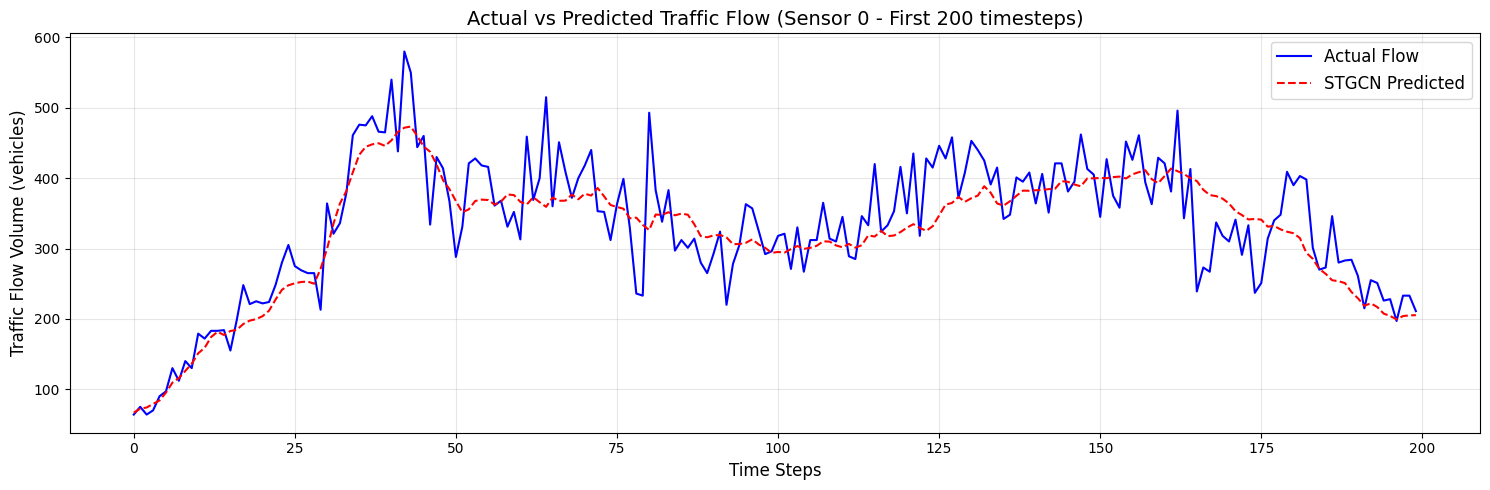

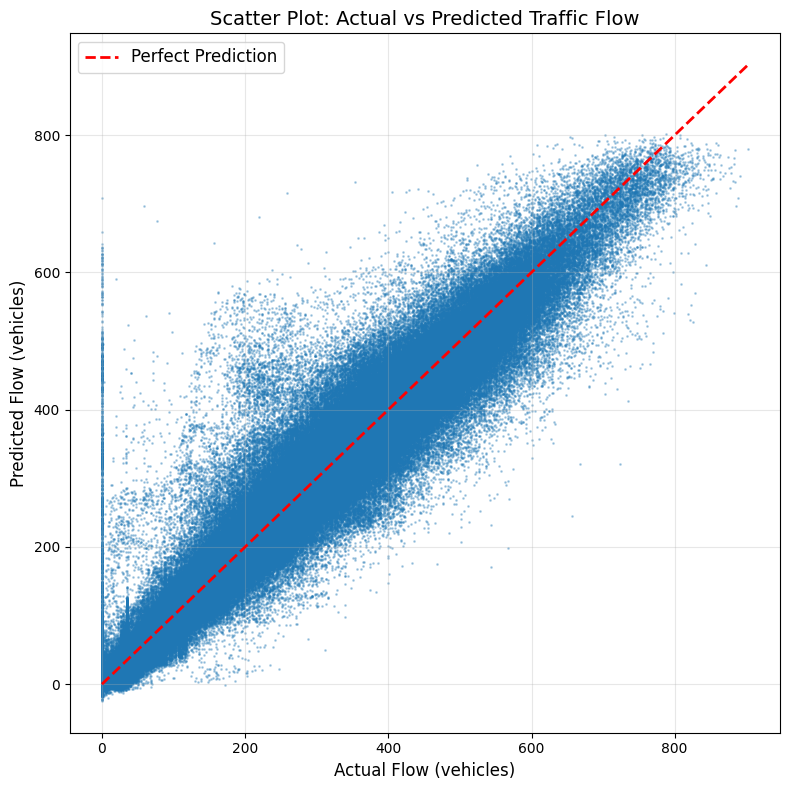

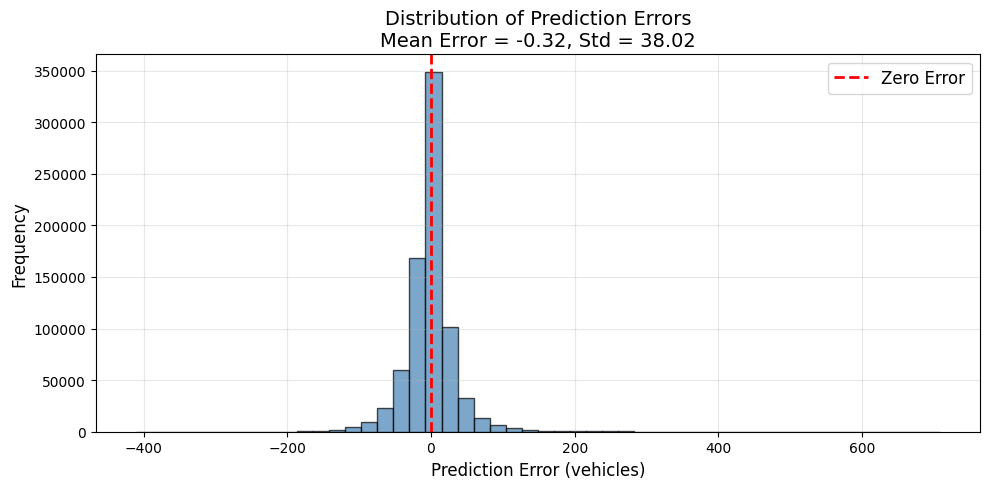

In [39]:
plt.figure(figsize=(15, 5))
plt.plot(true_rescaled[:200, 0], label='Actual Flow', color='blue', linewidth=1.5)
plt.plot(preds_rescaled[:200, 0], label='STGCN Predicted', color='red', linestyle='--', linewidth=1.5)
plt.title('Actual vs Predicted Traffic Flow (Sensor 0 - First 200 timesteps)', fontsize=14)
plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Traffic Flow Volume (vehicles)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('prediction_vs_actual_sensor0.png', dpi=150)
plt.show()

# Biểu đồ 2: Scatter plot dự đoán vs thực tế
plt.figure(figsize=(8, 8))
plt.scatter(true_rescaled.flatten(), preds_rescaled.flatten(), alpha=0.3, s=1)
plt.plot([true_rescaled.min(), true_rescaled.max()],
         [true_rescaled.min(), true_rescaled.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Flow (vehicles)', fontsize=12)
plt.ylabel('Predicted Flow (vehicles)', fontsize=12)
plt.title('Scatter Plot: Actual vs Predicted Traffic Flow', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('scatter_plot.png', dpi=150)
plt.show()

# Biểu đồ 3: Histogram lỗi dự đoán
errors = (preds_rescaled - true_rescaled).flatten()
plt.figure(figsize=(10, 5))
plt.hist(errors, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
plt.xlabel('Prediction Error (vehicles)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title(f'Distribution of Prediction Errors\nMean Error = {np.mean(errors):.2f}, Std = {np.std(errors):.2f}', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('error_distribution.png', dpi=150)
plt.show()

# 8. LƯU KẾT QUẢ ĐỂ BÁO CÁO


In [41]:
# ============================================
# 8. LƯU KẾT QUẢ ĐỂ BÁO CÁO (ĐÃ SỬA LỖI JSON)
# ============================================
import json

# Chuyển đổi numpy types sang Python types
results = {
    'MAE': float(mae),
    'RMSE': float(rmse),
    'sMAPE': float(smape_value),
    'WMAPE': float(wmape_value)
}

# Lưu file JSON
with open('evaluation_results.json', 'w') as f:
    json.dump(results, f, indent=4)

print("\nĐã lưu kết quả vào 'evaluation_results.json'")
print("Đã lưu model tốt nhất vào 'best_stgcn_model.pth'")

# In ra màn hình để kiểm tra
print("\n" + "="*50)
print("THÔNG TIN ĐÃ LƯU:")
print("="*50)
for key, value in results.items():
    print(f"{key}: {value:.4f}")
print("="*50)


Đã lưu kết quả vào 'evaluation_results.json'
Đã lưu model tốt nhất vào 'best_stgcn_model.pth'

THÔNG TIN ĐÃ LƯU:
MAE: 22.5009
RMSE: 38.0167
sMAPE: 15.6737
WMAPE: 10.1252


In [42]:
# ============================================
# BASELINE: GRU Model (để so sánh với STGCN)
# ============================================
class GRUModel(nn.Module):
    def __init__(self, num_nodes, seq_len, hidden_dim=64):
        super().__init__()
        self.gru = nn.GRU(input_size=num_nodes, hidden_size=hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_nodes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        # x: (batch, seq_len, num_nodes)
        _, gru_out = self.gru(x)
        return self.fc(gru_out.squeeze(0))

# Huấn luyện GRU baseline
gru_model = GRUModel(num_nodes, sequence_length).cuda()
optimizer_gru = torch.optim.Adam(gru_model.parameters(), lr=0.001)
criterion = nn.MSELoss()

print("\n--- BẮT ĐẦU HUẤN LUYỆN GRU BASELINE ---")
best_val_loss_gru = float('inf')
for epoch in range(30):
    gru_model.train()
    total_loss = 0
    for bx, by in train_loader:
        optimizer_gru.zero_grad()
        loss = criterion(gru_model(bx), by)
        loss.backward()
        optimizer_gru.step()
        total_loss += loss.item()

    # Validation
    gru_model.eval()
    val_loss = 0
    with torch.no_grad():
        for bx, by in val_loader:
            loss = criterion(gru_model(bx), by)
            val_loss += loss.item()
    avg_val_loss = val_loss / len(val_loader)

    if (epoch + 1) % 5 == 0:
        print(f"GRU Epoch {epoch+1}: Train Loss = {total_loss/len(train_loader):.5f}, Val Loss = {avg_val_loss:.5f}")

# Đánh giá GRU
gru_model.eval()
with torch.no_grad():
    gru_predictions = gru_model(X_test).cpu().numpy()
    gru_preds_rescaled = scaler.inverse_transform(gru_predictions)

# Tính metrics cho GRU
gru_mae = mean_absolute_error(true_rescaled, gru_preds_rescaled)
gru_rmse = np.sqrt(mean_squared_error(true_rescaled, gru_preds_rescaled))
gru_smape = smape(true_rescaled, gru_preds_rescaled)
gru_wmape = wmape(true_rescaled, gru_preds_rescaled)

print("\n" + "="*50)
print("KẾT QUẢ GRU BASELINE")
print("="*50)
print(f"MAE: {gru_mae:.4f} vehicles")
print(f"RMSE: {gru_rmse:.4f} vehicles")
print(f"sMAPE: {gru_smape:.2f}%")
print(f"WMAPE: {gru_wmape:.2f}%")
print("="*50)


--- BẮT ĐẦU HUẤN LUYỆN GRU BASELINE ---
GRU Epoch 5: Train Loss = 0.00478, Val Loss = 0.00503
GRU Epoch 10: Train Loss = 0.00387, Val Loss = 0.00447
GRU Epoch 15: Train Loss = 0.00347, Val Loss = 0.00427
GRU Epoch 20: Train Loss = 0.00323, Val Loss = 0.00406
GRU Epoch 25: Train Loss = 0.00306, Val Loss = 0.00394
GRU Epoch 30: Train Loss = 0.00295, Val Loss = 0.00378

KẾT QUẢ GRU BASELINE
MAE: 22.6027 vehicles
RMSE: 36.8032 vehicles
sMAPE: 16.24%
WMAPE: 10.17%


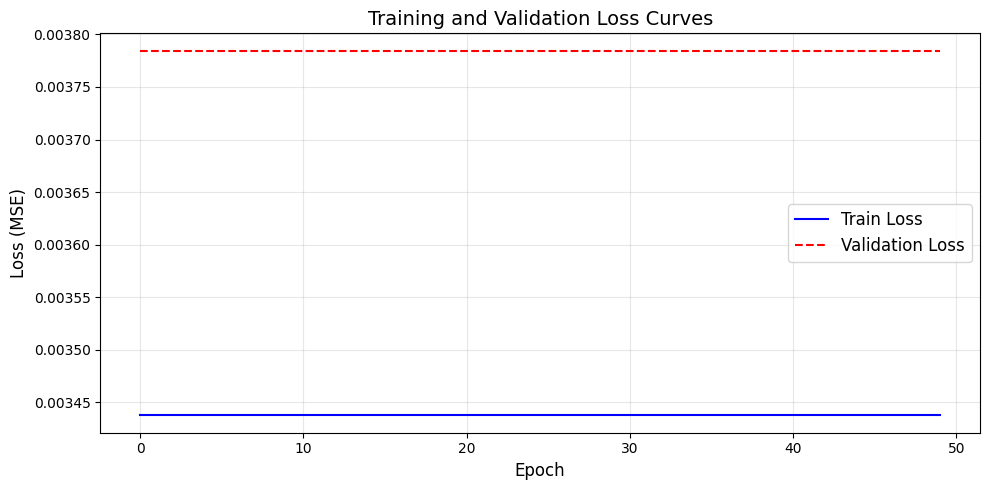

In [43]:
# Thêm vào code train (lưu loss mỗi epoch)
train_losses = []
val_losses = []

for epoch in range(50):
    # ... (code train hiện tại)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    # ...

# Vẽ loss curve
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', color='blue', linewidth=1.5)
plt.plot(val_losses, label='Validation Loss', color='red', linestyle='--', linewidth=1.5)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Training and Validation Loss Curves', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()

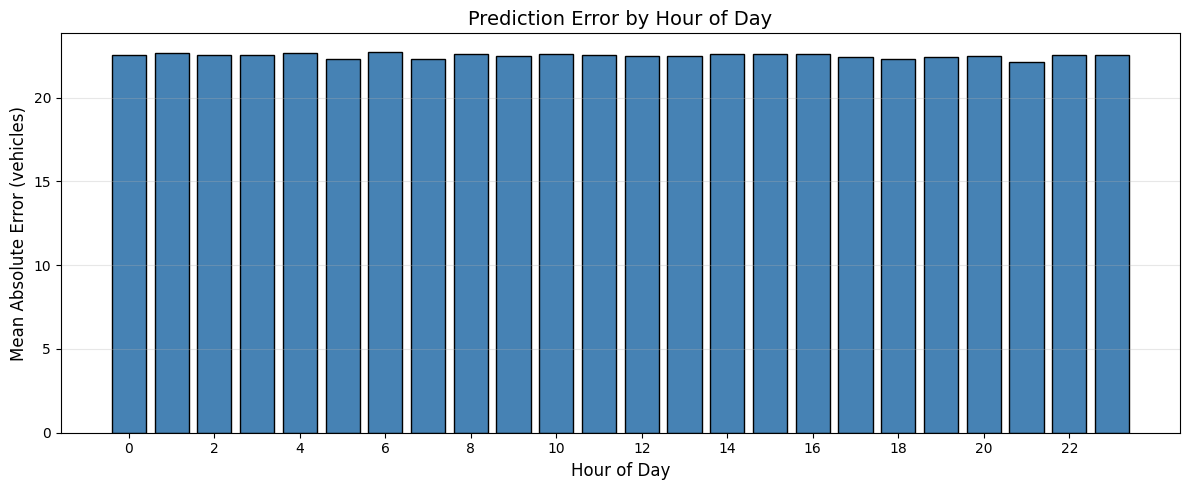


--- PHÂN TÍCH LỖI THEO GIỜ ---
Lỗi thấp nhất vào 21h: 22.13 vehicles
Lỗi cao nhất vào 6h: 22.69 vehicles


In [44]:
# ============================================
# PHÂN TÍCH LỖI THEO GIỜ TRONG NGÀY
# ============================================
# Giả sử mỗi timestep = 5 phút, 1 ngày = 288 timesteps
timesteps_per_day = 288
errors = (preds_rescaled - true_rescaled).flatten()

# Tạo mảng giờ (0-23) cho mỗi prediction
hours = np.tile(np.arange(24), len(errors) // 24 + 1)[:len(errors)]

# Tính MAE theo từng giờ
mae_by_hour = []
for hour in range(24):
    hour_errors = errors[hours == hour]
    mae_by_hour.append(np.mean(np.abs(hour_errors)))

# Vẽ biểu đồ
plt.figure(figsize=(12, 5))
plt.bar(range(24), mae_by_hour, color='steelblue', edgecolor='black')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Mean Absolute Error (vehicles)', fontsize=12)
plt.title('Prediction Error by Hour of Day', fontsize=14)
plt.xticks(range(0, 24, 2))
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('error_by_hour.png', dpi=150)
plt.show()

print("\n--- PHÂN TÍCH LỖI THEO GIỜ ---")
print(f"Lỗi thấp nhất vào {np.argmin(mae_by_hour)}h: {np.min(mae_by_hour):.2f} vehicles")
print(f"Lỗi cao nhất vào {np.argmax(mae_by_hour)}h: {np.max(mae_by_hour):.2f} vehicles")